# CS4603 PA4 — Document Analyst

Development & testing notebook. Section headers match the tasks in `README.md`.
Fill in each cell, run everything top-to-bottom, and **keep all outputs visible** before submitting.
Record explanations and analysis answers in `STUDENT_ANALYSIS.md`.


## Part 0 — Setup & Corpus Ingestion
Env config + ingest `data/annual_report.pdf` into Databricks Vector Search (Task 0.3).


In [2]:
# TODO(0.1): load config / verify env vars
# from config import ...



In [ ]:
spark.sql("CREATE CATALOG IF NOT EXISTS ali_pa4")
spark.sql("CREATE SCHEMA IF NOT EXISTS ali_pa4.rag")

In [0]:
spark.sql("CREATE VOLUME IF NOT EXISTS ali_pa4.rag.pa4_data")

DataFrame[]

In [0]:
dbutils.library.restartPython()

In [0]:
display(spark.sql("SHOW CATALOGS"))

catalog
ali_pa4
cs4603
samples
system
workspace


In [0]:
display(spark.sql("SHOW SCHEMAS IN ali_pa4"))

databaseName
default
information_schema
rag


In [0]:
workspace_path = "/Workspace/Users/alihasnainkiani@gmail.com/Drafts/annual_report.pdf" 
dbutils.fs.cp(f"file:{workspace_path}", "/Volumes/ali_pa4/rag/pa4_data/annual_report.pdf")

True

In [0]:
# TODO(0.3): ingest corpus -> Delta table -> Vector Search index; wait until READY

from rag.ingest import build_chunks_table, create_index

volume_path = "/Volumes/ali_pa4/rag/pa4_data/annual_report.pdf"
chunks_table = "ali_pa4.rag.ali_analyst_chunks"

print("Building chunks table...")
build_chunks_table(spark, volume_path, chunks_table)

print("Creating Vector Search index...")
create_index(chunks_table)

Building chunks table...
Creating Vector Search index...
[NOTICE] Using a notebook authentication token. Recommended for development only. For improved performance, please use Service Principal based authentication. To disable this message, pass disable_notice=True.
Creating Vector Search endpoint: ali-vs-endpoint...
Waiting for endpoint ali-vs-endpoint to be ready...
Creating Vector Search index: ali_pa4.rag.ali_analyst_index...


In [0]:
index = client.get_index(endpoint_name="ali-vs-endpoint", index_name="ali_pa4.rag.ali_analyst_index")
desc = index.describe()
print(json.dumps(desc, indent=2, default=str))

{
  "name": "ali_pa4.rag.ali_analyst_index",
  "endpoint_name": "ali-vs-endpoint",
  "primary_key": "chunk_id",
  "index_type": "DELTA_SYNC",
  "delta_sync_index_spec": {
    "source_table": "ali_pa4.rag.ali_analyst_chunks",
    "embedding_source_columns": [
      {
        "name": "chunk_to_embed",
        "embedding_model_endpoint_name": "databricks-gte-large-en"
      }
    ],
    "pipeline_type": "TRIGGERED",
    "pipeline_id": "5f40a0a7-e78e-458f-b4d8-f3dd7bc8a274"
  },
  "status": {
    "detailed_state": "PROVISIONING_PIPELINE_RESOURCES",
    "message": "Index is currently pending setup of pipeline resources. Check latest status: https://dbc-69b940e6-18e5.cloud.databricks.com/explore/data/ali_pa4/rag/ali_analyst_index",
    "indexed_row_count": 0,
    "provisioning_status": {
      "provisioning_pipeline_time_spent_seconds": 11.0
    },
    "ready": false,
    "index_url": "dbc-69b940e6-18e5.cloud.databricks.com/api/2.0/vector-search/indexes/ali_pa4.rag.ali_analyst_index"
  },
  

In [0]:
import json
print(json.dumps(client.get_endpoint("ali-vs-endpoint"), indent=2, default=str))

{
  "name": "ali-vs-endpoint",
  "creator": "alihasnainkiani@gmail.com",
  "creation_timestamp": 1784366470639,
  "last_updated_timestamp": 1784366470639,
  "endpoint_type": "STANDARD",
  "last_updated_user": "alihasnainkiani@gmail.com",
  "id": "8d945af8-520f-4e1f-85bf-408f8f36d2ce",
  "endpoint_status": {
    "state": "ONLINE"
  },
  "num_indexes": 1
}


In [0]:
test = index.similarity_search(
    query_text="What is in the annual report?",
    columns=["chunk_id", "chunk_to_retrieve", "source"],
    num_results=3,
)

if test.get("result", {}).get("data_array"):
    print("Index is queryable.")
    for row in test["result"]["data_array"]:
        print(row)
else:
    print("No results returned — check the query or the data.")

[NOTICE] Using a notebook authentication token. Recommended for development only. For improved performance, please use Service Principal based authentication. To disable this message, pass disable_notice=True.
Index is queryable.
['a9f20c9a992d4e6a892e0cc22a4e521a_0', '\nAnnual Report\n\nFor the fiscal year ended March 31, 2023 (FY2023)\n\nTokyo Stock Exchange (Prime Market) · Code 7000\n\n<table><tr><td>Letter from the President and CEO</td><td>3</td></tr><tr><td>Financial Highlights — Five-Year Summary</td><td>4</td></tr><tr><td>Consolidated Statement of Operations</td><td>5</td></tr><tr><td>About Meridian Motor Corporation</td><td>6</td></tr><tr><td>Segment Information</td><td>7</td></tr><tr><td>Regional Performance</td><td>8</td></tr><tr><td>Consolidated Balance Sheet</td><td>9</td></tr><tr><td>Consolidated Statements of Cash Flows</td><td>10</td></tr><tr><td>Research & Development and Capital Investment</td><td>11</td></tr><tr><td>Risk Factors</td><td>12</td></tr><tr><td>Outlook a

## Part 1 — Build the Document Analyst graph
Nodes: planner (1.2), supervisor (1.3), RAG agent (1.4), MCP tools (1.5), synthesizer (1.6), full graph (1.7).


In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('.'))

from langgraph.graph import StateGraph, START, END
from langchain_core.messages import HumanMessage

from agent.state import AnalystState
from agent.planner import make_planner
from agent.supervisor import make_supervisor, route_from_supervisor, RAG, MCP, SYNTH
from agent.rag_agent import make_rag_agent
from agent.synthesizer import make_synthesizer
from agent.graph import load_mcp_tools, make_mcp_node
from config import get_chat_llm
from rag.store import get_retriever

llm       = get_chat_llm()
retriever = get_retriever(k=4)
tools     = load_mcp_tools()

planner     = make_planner(llm)
supervisor  = make_supervisor(llm)
rag_agent   = make_rag_agent(retriever, llm)
mcp_tools   = make_mcp_node(tools, llm)
synthesizer = make_synthesizer(llm)

builder = StateGraph(AnalystState)
builder.add_node("planner",     planner)
builder.add_node("supervisor",  supervisor)
builder.add_node("rag_agent",   rag_agent)
builder.add_node("mcp_tools",   mcp_tools)
builder.add_node("synthesizer", synthesizer)

builder.add_edge(START, "planner")
builder.add_edge("planner", "supervisor")

builder.add_conditional_edges(
    "supervisor",
    route_from_supervisor,
    {RAG: RAG, MCP: MCP, SYNTH: SYNTH},
)
builder.add_edge("rag_agent",   "supervisor")
builder.add_edge("mcp_tools",   "supervisor")
builder.add_edge("synthesizer", END)

graph = builder.compile()
print("Graph compiled successfully.")


/home/alihasnain/CS 4603/cs4603-pa4/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Graph compiled successfully.


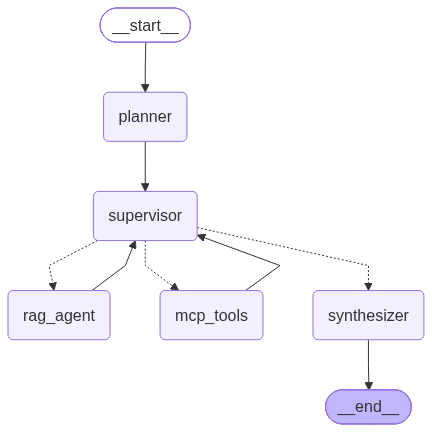

In [2]:
# TODO(1.7): visualize the compiled graph
from IPython.display import Image
Image(graph.get_graph().draw_mermaid_png())



### Test the graph


In [3]:
# Retrieval-only query
graph.invoke({'messages':[{'role':'user','content':'What was the net income in 2023?'}]})



[NOTICE] Using a notebook authentication token. Recommended for development only. For improved performance, please use Service Principal based authentication. To disable this message, pass disable_notice=True.


{'messages': [HumanMessage(content='What was the net income in 2023?', additional_kwargs={}, response_metadata={}, id='e4d72d1a-e365-4fc0-9502-ec3b29566bbc'),
  AIMessage(content="The net income for the year 2023 was ¥1,107 billion, as reported in the company's annual report [source: annual_report.pdf]. This figure is specifically noted in the income statement for FY2023, providing a clear picture of the company's financial performance during that period. Although the exact page number is not specified, the information is directly sourced from the annual report, ensuring its accuracy and reliability for financial analysis purposes.", additional_kwargs={}, response_metadata={}, id='e0facddc-6daf-4dd1-af0e-55e1d49c9d11', tool_calls=[], invalid_tool_calls=[])],
 'plan': ['Find the net income for FY2023 from the income statement in the annual report'],
 'current_step_index': 1,
 'step_results': ['Net income for FY2023 is ¥1,107 billion, source: dbfs:/Volumes/ali_pa4/rag/pa4_data/annual_rep

In [4]:
# Computation-only query
graph.invoke({'messages':[{'role':'user','content':'What is 15% of 2.4 billion?'}]})



{'messages': [HumanMessage(content='What is 15% of 2.4 billion?', additional_kwargs={}, response_metadata={}, id='7070dcb4-be11-42a9-84fc-342819642259'),
  AIMessage(content='To find 15% of 2.4 billion, we first define the principal amount as 2.4 billion, which is equivalent to 2.4e+09 ones [source: Step 1]. Then, we calculate 15% of this principal amount by multiplying 2.4e+09 by 0.15 [source: Step 2]. The result of this calculation is 3.6e+08, which is equivalent to 360 million. Therefore, 15% of 2.4 billion is 360 million [calculation: Step 2].', additional_kwargs={}, response_metadata={}, id='f2c5b0f2-c00b-48db-a55e-7147b1f3dfd5', tool_calls=[], invalid_tool_calls=[])],
 'plan': ['Define the principal amount as 2.4 billion',
  'Calculate 15% of the principal amount'],
 'current_step_index': 2,
 'step_results': ['2.4 billion = 2.4e+09 ones', '2.4e+09 * 0.15 = 3.6e+08'],
 'next_agent': 'synthesizer',
 'final_answer': 'To find 15% of 2.4 billion, we first define the principal amount a

In [5]:
# Combined query — show the full step-by-step execution trace
graph.invoke({'messages':[{'role':'user','content':'What was the revenue in 2023, and what would a 10% increase look like?'}]})



[NOTICE] Using a notebook authentication token. Recommended for development only. For improved performance, please use Service Principal based authentication. To disable this message, pass disable_notice=True.


{'messages': [HumanMessage(content='What was the revenue in 2023, and what would a 10% increase look like?', additional_kwargs={}, response_metadata={}, id='d5635bf8-6510-46d7-99ab-bfe08f733c09'),
  AIMessage(content="According to the company's annual report, the net revenue for FY2023 was ¥16,910 billion [source: annual_report.pdf]. To determine what a 10% increase would look like, we calculated this amount based on the net revenue found [calculation: step 2]. A 10% increase on the net revenue of ¥16,910 billion would result in ¥18,601 billion [calculation: step 2]. Therefore, the original revenue in 2023 was ¥16,910 billion, and a 10% increase would be ¥18,601 billion.", additional_kwargs={}, response_metadata={}, id='1551994e-0a4f-43d5-aeaa-eff194617bc6', tool_calls=[], invalid_tool_calls=[])],
 'plan': ["Find the company's net revenue for FY2023 from the annual report",
  'Calculate a 10% increase on the net revenue found in step 1',
  'Report both the original revenue and the calc

### Required — offline smoke test
Runs the graph with a mocked LLM (no Databricks calls). Same test Bonus A automates.


In [6]:
!python -m pytest tests/test_smoke.py -q


...                                                                      [100%]


## Part 2 — Deployment
Package as an MLflow models-from-code model, register in Unity Catalog, create the serving endpoint (Tasks 2.1–2.4).
Reference: `databricks_deployment_v1/deployment.ipynb`.


In [1]:
# TODO(2.1): sanity-check the model definition imports cleanly
!python -c "import deployment.agent_model"

Processing request of type ListToolsRequest


In [2]:
# TODO(2.2): log + register the model version in Unity Catalog
import os, sys
sys.path.insert(0, os.path.abspath('.'))
from deployment.deploy import log_and_register
uc_name, version = log_and_register()

/home/alihasnain/CS 4603/cs4603-pa4/.venv/lib/python3.12/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
If you are using MLflow Tracing, you can migrate your traces to Unity Catalog for unlimited storage, fine-grained access controls, and queryability from notebooks, SQL, and dashboards. Learn more: https://docs.databricks.com/aws/en/mlflow3/genai/tracing/migrate-traces-to-uc
2026/07/18 18:50:31 INFO mlflow.utils.uv_utils: Detected uv project: found uv.lock and pyproject.toml in /home/alihasnain/CS 4603/cs4603-pa4


[NOTICE] Using a notebook authentication token. Recommended for development only. For improved performance, please use Service Principal based authentication. To disable this message, pass disable_notice=True.


/home/alihasnain/CS 4603/cs4603-pa4/.venv/lib/python3.12/site-packages/mlflow/types/utils.py:440: UserWarning: Hint: Inferred schema contains integer column(s). Integer columns in Python cannot represent missing values. If your input data contains missing values at inference time, it will be encoded as floats and will cause a schema enforcement error. The best way to avoid this problem is to infer the model schema based on a realistic data sample (training dataset) that includes missing values. Alternatively, you can declare integer columns as doubles (float64) whenever these columns may have missing values. See `Handling Integers With Missing Values <https://www.mlflow.org/docs/latest/models.html#handling-integers-with-missing-values>`_ for more details.
  warnings.warn(
2026/07/18 18:50:50 INFO mlflow: Attempting to auto-detect Databricks resource dependencies for the current langchain model. Dependency auto-detection is best-effort and may not capture all dependencies of your langch

[NOTICE] Using a notebook authentication token. Recommended for development only. For improved performance, please use Service Principal based authentication. To disable this message, pass disable_notice=True.


2026/07/18 18:51:00 INFO mlflow.models.model: Found the following environment variables used during model inference: [DATABRICKS_HOST, DATABRICKS_TOKEN]. Please check if you need to set them when deploying the model. To disable this message, set environment variable `MLFLOW_RECORD_ENV_VARS_IN_MODEL_LOGGING` to `false`.


🏃 View run luxuriant-bee-635 at: https://dbc-69b940e6-18e5.cloud.databricks.com/ml/experiments/3328470866436071/runs/26172d31742c45109218670189d77348
🧪 View experiment at: https://dbc-69b940e6-18e5.cloud.databricks.com/ml/experiments/3328470866436071


Registered model 'ali_pa4.rag.alihasnain_pa4_analyst_model' already exists. Creating a new version of this model...
Uploading artifacts: 100%|██████████| 24/24 [00:13<00:00,  1.76it/s]
Created version '7' of model 'ali_pa4.rag.alihasnain_pa4_analyst_model'.


Registered model version: 7


In [3]:
# TODO(2.3): create/update the serving endpoint; wait for READY; print the URL
from deployment.deploy import create_or_update_endpoint
endpoint_url = create_or_update_endpoint(uc_name, version)


Deploying endpoint: alihasnain-pa4-analyst-endpoint...
Creating endpoint...
Waiting for endpoint to reach READY state...
Endpoint 'alihasnain-pa4-analyst-endpoint' is READY at: https://dbc-69b940e6-18e5.cloud.databricks.com/serving-endpoints/alihasnain-pa4-analyst-endpoint/invocations


### Test the deployed endpoint (Task 2.4)


In [7]:
# curl the endpoint and show the raw response
import os
host = os.environ.get('DATABRICKS_HOST', '')
token = os.environ.get('DATABRICKS_TOKEN', '')
user = os.environ.get('USER', 'student')
endpoint_name = f'{user}-pa4-analyst-endpoint'
print(f'HOST: {host!r}')
print(f'TOKEN present: {bool(token)}, length: {len(token)}')
url = f'{host}/serving-endpoints/{endpoint_name}/invocations'
print(f'Endpoint URL: {url}')

!curl -s -X POST -H 'Authorization: Bearer {token}' \
  -H 'Content-Type: application/json' \
  -d '{"messages": [{"role": "user", "content": "What was the net income in 2023?"}]}' \
  {url}


HOST: 'https://dbc-69b940e6-18e5.cloud.databricks.com'
TOKEN present: True, length: 36
Endpoint URL: https://dbc-69b940e6-18e5.cloud.databricks.com/serving-endpoints/alihasnain-pa4-analyst-endpoint/invocations


In [8]:
import requests
import time

def query_endpoint(question):
    start = time.time()
    resp = requests.post(url, headers={'Authorization': f'Bearer {token}'}, json={'messages': [{'role': 'user', 'content': question}]})
    latency = time.time() - start
    data = resp.json()
    try:
        answer = data[0]['messages'][-1]['content']
    except Exception:
        answer = data
    return answer, latency

ans, lat = query_endpoint('What was the net income in 2023?')
print(f'Answer: {ans}\nLatency: {lat:.2f}s')

print('-'*40)
q1 = 'What was the net income in 2023?'
q2 = 'What is 15% of 2.4 billion?'
q3 = 'What was the revenue in 2023, and what would a 10% increase look like?'
for q in [q1, q2, q3]:
    a, l = query_endpoint(q)
    print(f'Q: {q}\nA: {a}\n[Latency: {l:.2f}s]\n')


Answer: The net income for the year 2023 was ¥1,107 billion, as reported in the company's annual report [source: annual_report.pdf]. This figure is specifically noted for the fiscal year 2023, providing a clear picture of the company's financial performance during that period. It's worth noting that the exact page number in the annual report where this information can be found is not specified [source: annual_report.pdf, p.None], but the data itself confirms the net income amount.
Latency: 6.15s
----------------------------------------
Q: What was the net income in 2023?
A: The net income for the year 2023 was ¥1,107 billion, as reported in the company's annual report [source: annual_report.pdf]. This figure is specifically noted in the income statement section of the report, providing a clear overview of the company's financial performance for the fiscal year 2023. Although the exact page number is not specified, the information is directly sourced from the annual report, ensuring the

## Part 3 — Client SDK demo
Instantiate `DocumentAnalystClient`, health-check, ask, stream, and show timeout/retry handling (Task 3.2).


In [1]:
import os
from client.sdk import DocumentAnalystClient

user = os.environ.get('USER', 'student')
endpoint_name = f'{user}-pa4-analyst-endpoint'

c = DocumentAnalystClient(endpoint_name)
assert c.health_check() is True
print(c.ask('What was the net income in 2023?'))


The net income for the year 2023 was ¥1,107 billion, as reported in the annual report [source: annual_report.pdf]. This figure is specifically noted as the net income for FY2023, providing a clear indication of the company's financial performance during that period. It's worth noting that the page number in the annual report where this information can be found was not specified [source: annual_report.pdf, p.None]. Nonetheless, according to the information available, ¥1,107 billion represents the net income achieved in 2023.


In [2]:
# ask_streaming demo
for chunk in c.ask_streaming('Summarize FY2023 revenue.'):
    print(chunk, end='', flush=True)
print()


Meridian's revenue for FY2023 can be summarized as follows: the net revenue is ¥16,910 billion, as stated in the annual report [source: annual_report.pdf]. Although the gross revenue is not explicitly stated, the gross profit is reported to be ¥3,350 billion, which represents the difference between net revenue and cost of sales [source: annual_report.pdf]. However, it's essential to note that the calculation of total revenue by adding net and gross revenue, as performed in Step 3, is not a standard accounting practice. The result of this calculation, ¥20,260 billion [calculation: Step 3], does not accurately represent the total revenue. Instead, the net revenue of ¥16,910 billion remains the most reliable figure available for FY2023 revenue, as the gross revenue is not directly provided in the annual report.


In [3]:
# Simulate timeout (timeout=0.001)
c_timeout = DocumentAnalystClient(endpoint_name, timeout=0.001)
try:
    c_timeout.ask('What is the company name?')
except TimeoutError as e:
    print(f'Caught TimeoutError successfully: {e}')

# Simulate endpoint-unavailable retry behavior (using a non-existent endpoint)
c_unavailable = DocumentAnalystClient('non-existent-endpoint-12345', max_retries=1)
try:
    c_unavailable.ask('Will fail')
except Exception as e:
    print(f'Caught Exception for unavailable endpoint successfully: {e}')


Caught TimeoutError successfully: Request timed out after 0.31 seconds.
Caught Exception for unavailable endpoint successfully: Endpoint is not READY
